In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-c

In [2]:
# Import required Library
import json
import os
from PIL import Image
from collections import defaultdict
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, roc_curve, auc,
                              precision_recall_curve)
from sklearn.preprocessing import label_binarize
import numpy as np


In [3]:
#  Download the dataset
from roboflow import Roboflow
rf = Roboflow(api_key="VzmUla9fo3jv07L8R1T7")
project = rf.workspace("kiran-saud").project("human-face-emotions-nkhqc")
version = project.version(1)
dataset = version.download("coco")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Human-face-emotions-1 in coco:: 100%|██████████| 9405/9405 [00:01<00:00, 7235.00it/s]


In [4]:
BASE_PATH = "/kaggle/working/Human-face-emotions-1"
OUTPUT_PATH = "/kaggle/working/Emotions"
SELECTED_CLASSES = ["happy", "sad", "anger"]

for split in ["train", "valid", "test"]:

    split_path = os.path.join(BASE_PATH, split)
    ann_path   = os.path.join(split_path, "_annotations.coco.json")

    with open(ann_path, "r") as f:
        coco = json.load(f)

    category_map = {
        cat["id"]: cat["name"].lower()
        for cat in coco["categories"]
    }

    image_map = {
        img["id"]: img["file_name"]
        for img in coco["images"]
    }

    for cls in SELECTED_CLASSES:
        os.makedirs(os.path.join(OUTPUT_PATH, split, cls), exist_ok=True)

    # Group by image and class
    image_annotations = defaultdict(list)
    for ann in coco["annotations"]:
        cls_name = category_map.get(ann["category_id"], "").lower()
        if cls_name not in SELECTED_CLASSES:
            continue
        image_annotations[(ann["image_id"], cls_name)].append(ann)

    saved = {"happy": 0, "sad": 0, "anger": 0}

    for (img_id, cls_name), anns in image_annotations.items():

        # Always pick the largest bounding box
        best_ann = max(anns, key=lambda a: a["bbox"][2] * a["bbox"][3])

        img_file = image_map.get(img_id)
        img_path = os.path.join(split_path, img_file)

        if not os.path.exists(img_path):
            continue

        x, y, w, h = best_ann["bbox"]
        x, y, w, h = int(x), int(y), int(w), int(h)

        img = Image.open(img_path).convert("RGB")
        face = img.crop((x, y, x + w, y + h))

        out_name = f"{best_ann['id']}_{img_file}"
        out_path = os.path.join(OUTPUT_PATH, split, cls_name, out_name)
        face.save(out_path)
        saved[cls_name] += 1

    print(f"\n{split}:")
    for cls, count in saved.items():
        print(f"  {cls}: {count} images")

print("\nDone! Dataset ready.")


train:
  happy: 779 images
  sad: 827 images
  anger: 834 images

valid:
  happy: 208 images
  sad: 232 images
  anger: 235 images

test:
  happy: 114 images
  sad: 127 images
  anger: 109 images

Done! Dataset ready.


In [5]:
# Paths 
DATASET_PATH = "/kaggle/working/Emotions"

# Settings
IMG_SIZE   = 64 # Baseline Input size
# IMG_SIZE = 128 # Optimized CNN input size
BATCH_SIZE = 32

# Transforms 

# Training — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and Test with no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Datasets 
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "valid"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "test"),
    transform=val_test_transforms
)

# DataLoaders 
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Verify
print("Classes:", train_dataset.classes)
print("Class indices:", train_dataset.class_to_idx)
print(f"Train: {len(train_dataset)} images")
print(f"Valid: {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

# Check one batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels: {labels}")# 

Classes: ['anger', 'happy', 'sad']
Class indices: {'anger': 0, 'happy': 1, 'sad': 2}
Train: 2440 images
Valid: 675 images
Test:  350 images

Batch shape: torch.Size([32, 3, 64, 64])
Labels: tensor([0, 0, 0, 0, 1, 2, 2, 1, 2, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2,
        2, 2, 2, 1, 1, 2, 2, 0])


# Baseline CNN

In [6]:
model = nn.Sequential(

    # Feature extractor
    # Layer 1
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Layer 2
    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    # Layer 3
    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Flatten layer
    nn.Flatten(),
    nn.Linear(128 * 8 * 8, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 3)
)
          




In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 30
PATIENCE = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")
patience_counter = 0
best_model_path = "/kaggle/working/baseline_cnn_best.pth"

# Training Loop 
for epoch in range(EPOCHS):
    
    #  Training Phase
    model.train()
    
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0
    
    for images, labels in train_loader:
        # move batch to GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # clear old gradients
        optimizer.zero_grad()
        
        # forward pass — get predictions
        outputs = model(images)
        
        # 3. calculate loss
        loss = criterion(outputs, labels)
        
        # 4. backward pass — calculate gradients
        loss.backward()
        
        # 5. update weights
        optimizer.step()
        
        # track loss and accuracy
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        # torch.max returns highest score and its index
        # index = predicted class (0=anger, 1=happy, 2=sad)
        
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)
    
    # calculate epoch averages
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = train_correct / train_total * 100
    
    # Validation Phase 
    model.eval()
    # sets model to evaluation mode
    # disables dropout so all neurons are active
    
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0
    
    with torch.no_grad():
        # torch.no_grad() stops gradient calculation
        # saves memory and speeds up validation
        
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss    = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / val_total * 100
    
    # store for plotting later
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(avg_train_acc)
    val_accs.append(avg_val_acc)
    
    # print progress
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Train Acc: {avg_train_acc:.2f}% "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {avg_val_acc:.2f}%")
    
    # Early Stopping 
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # save best model
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved at epoch {epoch+1}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")
        
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTraining Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/30] Train Loss: 0.8666 Train Acc: 58.61% Val Loss: 0.7489 Val Acc: 68.59%
Best model saved at epoch 1
Epoch [2/30] Train Loss: 0.7910 Train Acc: 64.51% Val Loss: 0.7140 Val Acc: 68.74%
Best model saved at epoch 2
Epoch [3/30] Train Loss: 0.7289 Train Acc: 68.57% Val Loss: 0.6668 Val Acc: 72.74%
Best model saved at epoch 3
Epoch [4/30] Train Loss: 0.6868 Train Acc: 69.43% Val Loss: 0.6526 Val Acc: 70.07%
Best model saved at epoch 4
Epoch [5/30] Train Loss: 0.6837 Train Acc: 70.20% Val Loss: 0.6430 Val Acc: 70.96%
Best model saved at epoch 5
Epoch [6/30] Train Loss: 0.6526 Train Acc: 71.80% Val Loss: 0.5890 Val Acc: 75.26%
Best model saved at epoch 6
Epoch [7/30] Train Loss: 0.6239 Train Acc: 73.73% Val Loss: 0.5921 Val Acc: 73.63%
No improvement. Patience: 1/5
Epoch [8/30] Train Loss: 0.5947 Train Acc: 74.18% Val Loss: 0.6015 Val Acc: 74.22%
No improvement. Patience: 2/5
Epoch [9/30] Train Loss: 0.5722 Train Acc: 75.98% Val Loss: 0.6574 Val Acc: 70.52%
No improvement. Patience:

# Baseline CNN Evaluation

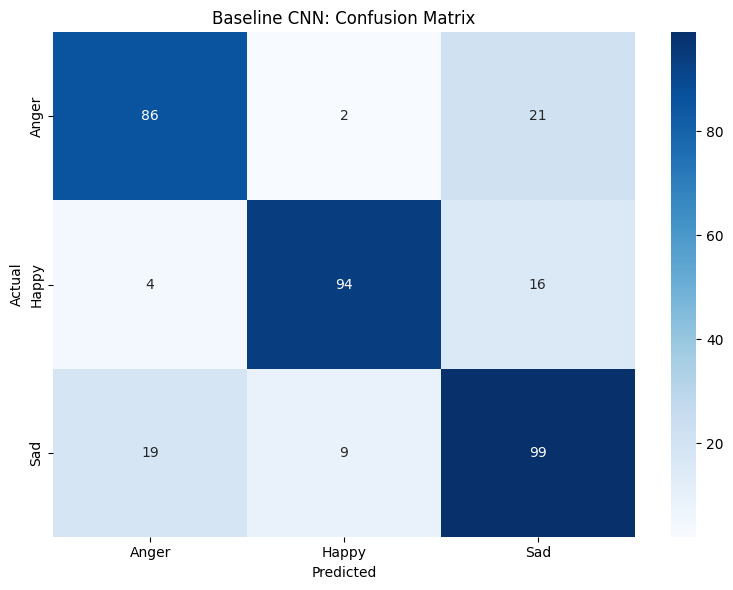

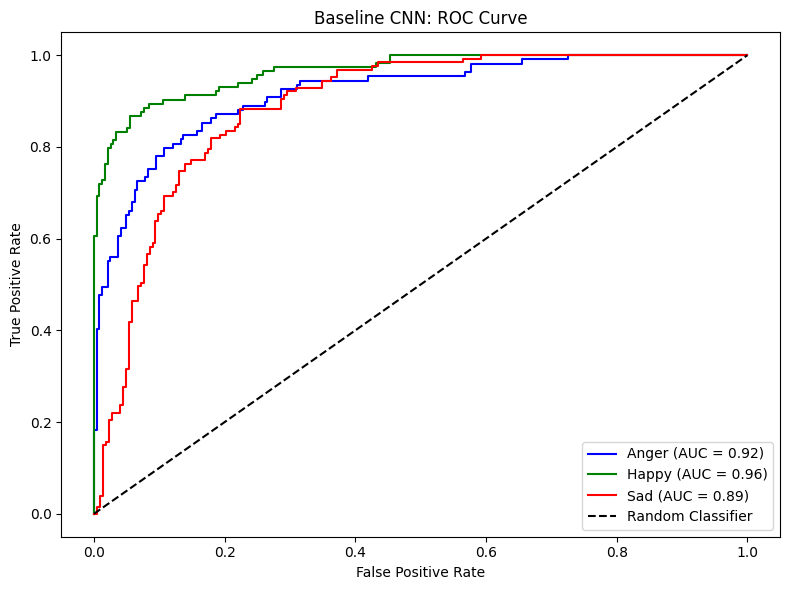

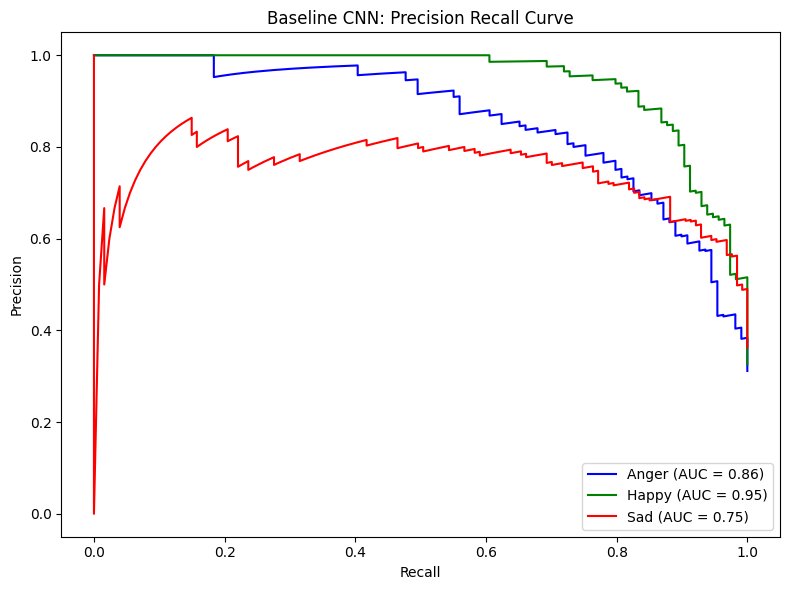

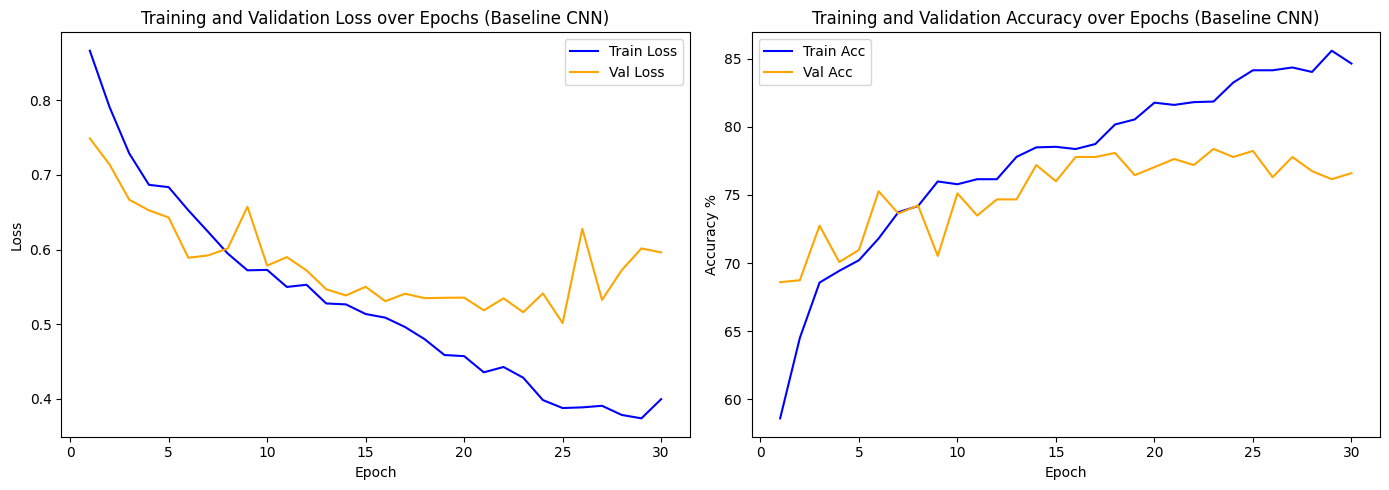

Test Accuracy: 79.71%

Classification Report:
              precision    recall  f1-score   support

       Anger       0.79      0.79      0.79       109
       Happy       0.90      0.82      0.86       114
         Sad       0.73      0.78      0.75       127

    accuracy                           0.80       350
   macro avg       0.80      0.80      0.80       350
weighted avg       0.80      0.80      0.80       350

All plots saved.


In [12]:
# Get Predictions and Probabilities 
model.load_state_dict(torch.load("/kaggle/working/baseline_cnn_best.pth"))
model.eval()

all_preds  = []
all_labels = []
# probabilities for ROC and PR curves
all_probs  = []   

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        labels  = labels.to(device)
        outputs = model(images)
        
        # get probabilities using softmax
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

class_names = ["Anger", "Happy", "Sad"]

# binarize labels for ROC and PR curves
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Baseline CNN: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/baseline_confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve 
plt.figure(figsize=(8, 6))
colors = ["blue", "green", "red"]

for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, 
             label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.title("Baseline CNN: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/baseline_roc_curve.png", dpi=150)
plt.show()

#  Precision Recall Curve 
plt.figure(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(
                            labels_bin[:, i], all_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color,
             label=f"{cls} (AUC = {pr_auc:.2f})")

plt.title("Baseline CNN: Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/Baseline_pr_curve.png", dpi=150)
plt.show()

# Training Curves 
epochs_ran = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, train_losses, label="Train Loss", color="blue")
ax1.plot(epochs_ran, val_losses,   label="Val Loss",   color="orange")
ax1.set_title("Training and Validation Loss over Epochs (Baseline CNN)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, train_accs, label="Train Acc", color="blue")
ax2.plot(epochs_ran, val_accs,   label="Val Acc",   color="orange")
ax2.set_title("Training and Validation Accuracy over Epochs (Baseline CNN)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/basline_training_curves.png", dpi=150)
plt.show()

# Print Results
print(f"Test Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("All plots saved.")

# Optimized CNN

In [11]:
import torch.nn as nn

model = nn.Sequential(

    # Feature extractor
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(128, 256, 3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Classifier
    nn.Flatten(),
    nn.Linear(256 * 8 * 8, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 3)
)

In [13]:
# Setup  for optimized CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = OptimisedCNN().to(device)

# weighted loss  to boost sad and anger
class_weights = torch.tensor([3.0, 1.0, 3.0]).to(device)
criterion     = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(model2.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(
    optimizer, mode='max',
    patience=3, factor=0.5
)

EPOCHS           = 50
PATIENCE         = 10
best_val_acc     = 0.0
patience_counter = 0
best_model_path2 = "/kaggle/working/optimised_cnn_best.pth"

train_losses2     = []
val_losses2       = []
train_accuracies2 = []
val_accuracies2   = []

# Training Loop
for epoch in range(EPOCHS):

    model2.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model2(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        _, predicted   = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total   += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = train_correct / train_total * 100

    model2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs      = model2(images)
            loss         = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted  = torch.max(outputs, 1)
            val_correct  += (predicted == labels).sum().item()
            val_total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / val_total * 100

    scheduler.step(avg_val_acc)
    
    train_losses2.append(avg_train_loss)
    val_losses2.append(avg_val_loss)
    train_accuracies2.append(avg_train_acc)
    val_accuracies2.append(avg_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Train Acc: {avg_train_acc:.2f}% "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {avg_val_acc:.2f}%")

    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        patience_counter = 0
        torch.save(model2.state_dict(), best_model_path2)
        print(f"  ✓ Best model saved at epoch {epoch+1} "
              f"Val Acc: {avg_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTraining Complete!")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")


Epoch [1/50] Train Loss: 2.1417 Train Acc: 36.27% Val Loss: 1.0880 Val Acc: 39.11%
  ✓ Best model saved at epoch 1 Val Acc: 39.11%
Epoch [2/50] Train Loss: 0.9839 Train Acc: 39.18% Val Loss: 1.1217 Val Acc: 43.70%
  ✓ Best model saved at epoch 2 Val Acc: 43.70%
Epoch [3/50] Train Loss: 0.9722 Train Acc: 39.92% Val Loss: 1.0761 Val Acc: 42.81%
  No improvement. Patience: 1/10
Epoch [4/50] Train Loss: 0.9681 Train Acc: 40.08% Val Loss: 1.0589 Val Acc: 39.26%
  No improvement. Patience: 2/10
Epoch [5/50] Train Loss: 0.9527 Train Acc: 42.42% Val Loss: 1.0743 Val Acc: 46.37%
  ✓ Best model saved at epoch 5 Val Acc: 46.37%
Epoch [6/50] Train Loss: 0.9341 Train Acc: 43.07% Val Loss: 1.0521 Val Acc: 46.22%
  No improvement. Patience: 1/10
Epoch [7/50] Train Loss: 0.9207 Train Acc: 43.89% Val Loss: 0.9943 Val Acc: 49.04%
  ✓ Best model saved at epoch 7 Val Acc: 49.04%
Epoch [8/50] Train Loss: 0.9004 Train Acc: 45.04% Val Loss: 1.0227 Val Acc: 47.85%
  No improvement. Patience: 1/10
Epoch [9/50]

# Optimized model evaluation

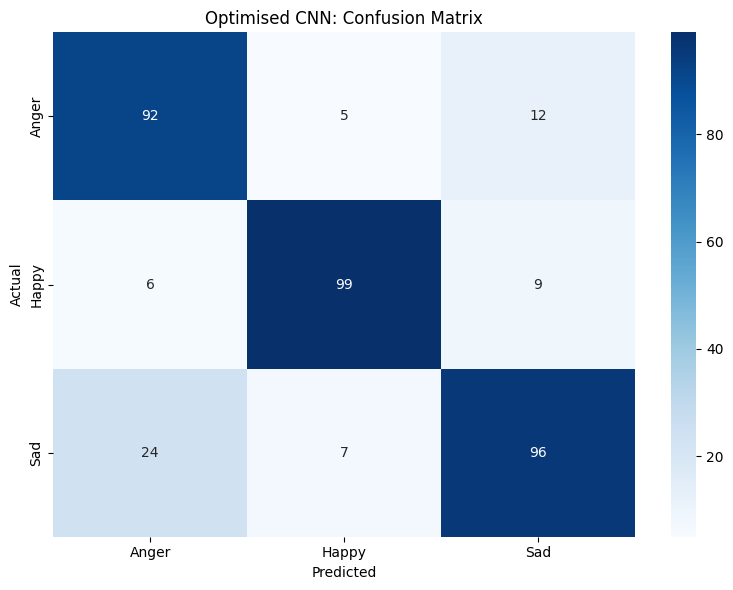

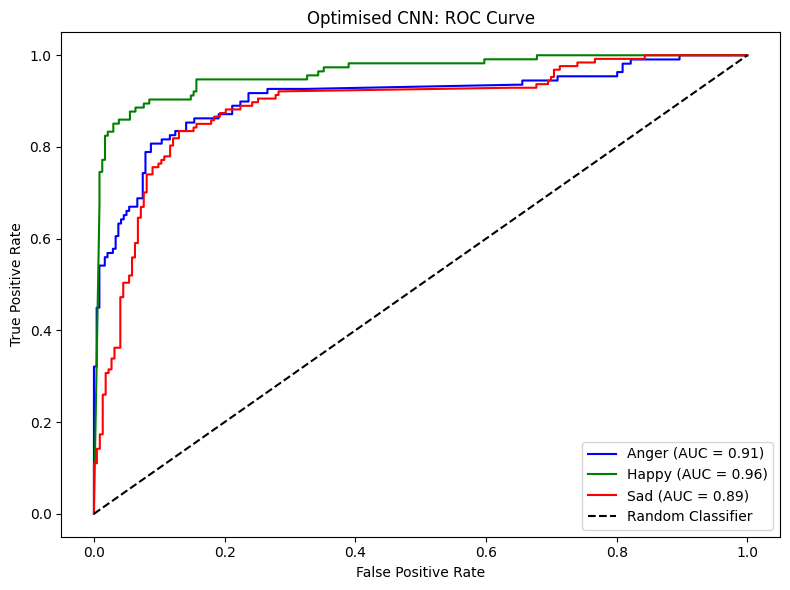

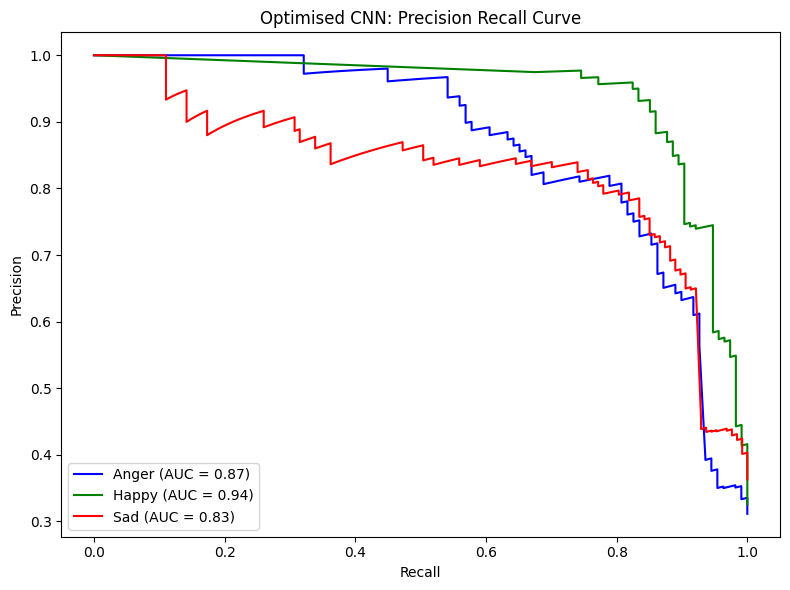

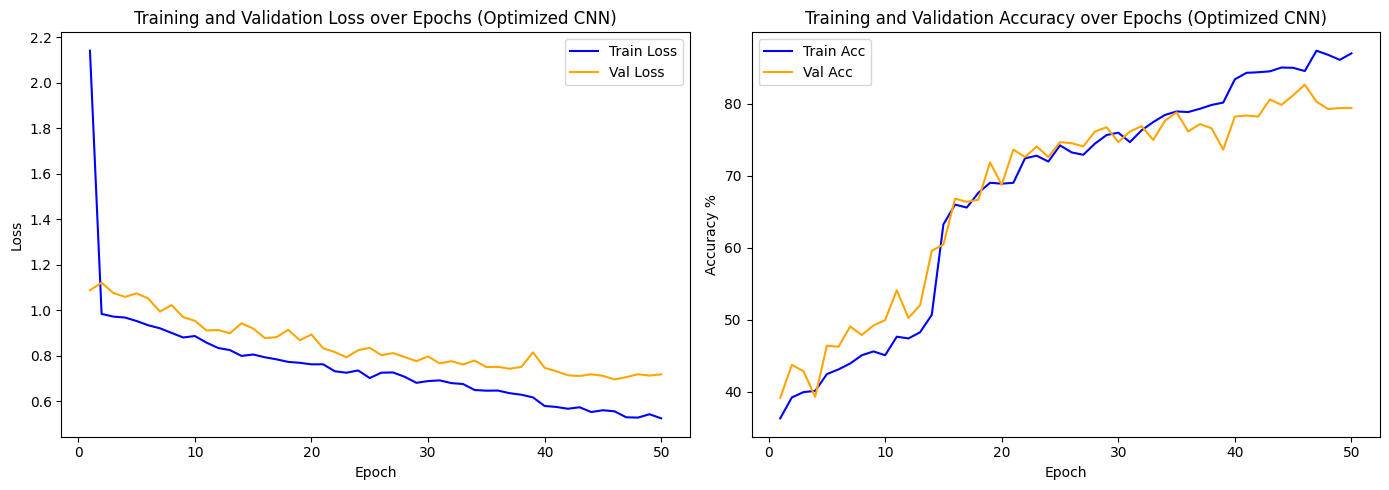

Test Accuracy: 82.00%

Classification Report:
              precision    recall  f1-score   support

       Anger       0.75      0.84      0.80       109
       Happy       0.89      0.87      0.88       114
         Sad       0.82      0.76      0.79       127

    accuracy                           0.82       350
   macro avg       0.82      0.82      0.82       350
weighted avg       0.82      0.82      0.82       350

All plots saved.


In [17]:
# Get Predictions and Probabilities 
model2.load_state_dict(torch.load("/kaggle/working/optimised_cnn_best.pth"))
model2.eval()

all_preds  = []
all_labels = []
# probabilities for ROC and PR curves
all_probs  = []   

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        labels  = labels.to(device)
        outputs = model2(images)
        
        # get probabilities using softmax
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

class_names = ["Anger", "Happy", "Sad"]

# binarize labels for ROC and PR curves
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Optimised CNN: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/optimised_confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve 
plt.figure(figsize=(8, 6))
colors = ["blue", "green", "red"]

for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, 
             label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.title("Optimised CNN: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/optimised_roc_curve.png", dpi=150)
plt.show()

#  Precision Recall Curve 
plt.figure(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(
                            labels_bin[:, i], all_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color,
             label=f"{cls} (AUC = {pr_auc:.2f})")

plt.title("Optimised CNN: Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/optimised_pr_curve.png", dpi=150)
plt.show()

# Training Curves 
epochs_ran = range(1, len(train_losses2) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, train_losses2, label="Train Loss", color="blue")
ax1.plot(epochs_ran, val_losses2,   label="Val Loss",   color="orange")
ax1.set_title("Training and Validation Loss over Epochs (Optimized CNN)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, train_accuracies2, label="Train Acc", color="blue")
ax2.plot(epochs_ran, val_accuracies2,   label="Val Acc",   color="orange")
ax2.set_title("Training and Validation Accuracy over Epochs (Optimized CNN)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/optimised_training_curves.png", dpi=150)
plt.show()

# Print Results
print(f"Test Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("All plots saved.")

# Pretrained model: MobileNet